# Muhammad Dawood Khan  

### Welcome to the **Best Place to Learn scikit-learn (SKLEARN)**  
Get ready for an **exciting journey** through Machine Learning with hands-on, practical examples.  
Buckle up, explore, and most importantly — **enjoy the ride!**  

---

### Happy Coding & Keep Learning!
If you have any **questions**, **feedback**, or **suggestions**, feel free to reach out anytime.  
I’m always happy to connect with fellow learners and developers!

---

### Connect With Me  
[![GitHub](https://img.shields.io/github/followers/Dawood-ML?label=GitHub&style=social)](https://github.com/Dawood-ML)  
[![LinkedIn](https://img.shields.io/badge/LinkedIn-0077B5?style=for-the-badge&logo=linkedin&logoColor=white)](https://www.linkedin.com/in/muhammad-dawood-khan-5a3292329/)

---

_“Learning never exhausts the mind — it only sharpens it.”_


### **Chunk 1: The Scikit-Learn API Philosophy**

#### **1. Concept Introduction**

You understand the theory behind machine learning models. Scikit-learn's genius is not in the algorithms themselves, but in its **unified API**. Every algorithm, whether it's a simple regression or a complex ensemble, is an "Estimator" object that shares the same simple, consistent methods. This is the key to productivity.

The three core methods are:

1.  `.fit(X, y)`: This is the **training** step. The estimator "learns" from your data `X` (features) and `y` (target). Every supervised learning model in scikit-learn has this method.
2.  `.predict(X_new)`: Once the model is trained, this method generates predictions for new, unseen data `X_new`.
3.  `.transform(X)`: This is for **preprocessing**. It takes data and returns a transformed version of it (e.g., scaled, encoded, or with imputed values). We will cover this more in the next chunk. `fit_transform()` is a convenient shortcut that learns the transformation parameters from the data and applies the transformation in one step.

This leads to the most fundamental workflow in all of supervised machine learning, which you will type thousands of times:

**Load Data → Split Data → Train Model → Predict → Evaluate**

Let's see this in action with our first dataset.

#### **2. Dataset EDA: The Iris Dataset**

The Iris dataset is the "hello, world" of machine learning. It's a clean, simple dataset for classifying three species of iris flowers based on four measurements.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Set Plot style
sns.set_style("whitegrid")

In [2]:
iris = load_iris()
# Create a Pandas DataFrame for easier manipulation
df = pd.DataFrame(data=iris.data, 
                    columns=iris.feature_names)

# Create target column
df['target'] = iris.target
df['species'] = df['target'].map({i: name for i, name in enumerate(iris.target_names)})

print("INFO")
df.info()

INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [3]:
# Incase you are wondering what this line does.
# Uncomment the code below

#{i: name for i, name in enumerate(iris.target_names)}

In [4]:
# Statistical summary
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [5]:
# First 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [6]:
# Check for missing values
print("MIssing Values")
df.isnull().sum()

MIssing Values


sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Target Variable Distribution


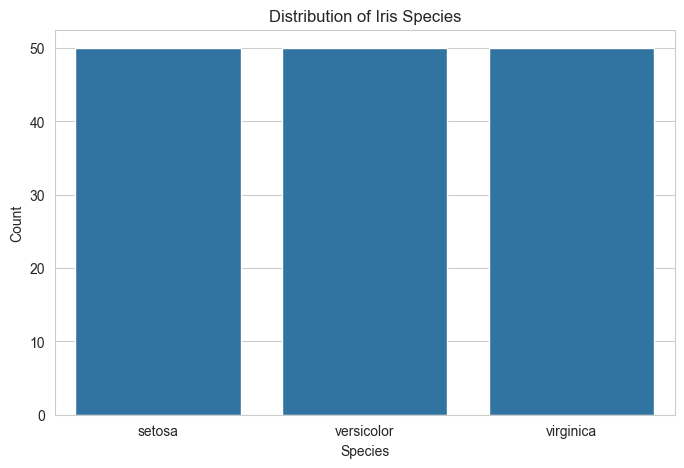

In [7]:
# Target Variable Distribution
print("Target Variable Distribution")
plt.figure(figsize=(8,5))
sns.countplot(x='species', data = df)
plt.title("Distribution of Iris Species")
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

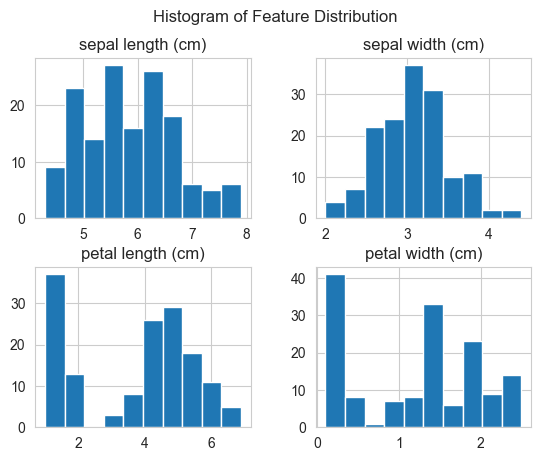

In [8]:
# Feature Distributions ( Histogram )
df[iris.feature_names].hist()
plt.suptitle('Histogram of Feature Distribution');



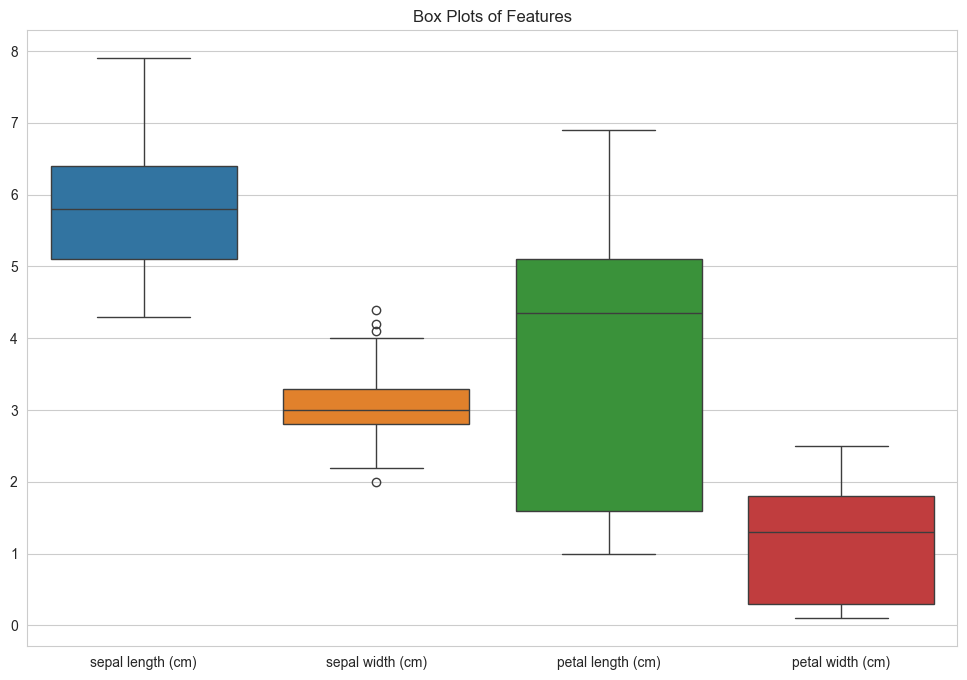

In [9]:
# Feature Distributions ( Box PLots )
plt.figure(figsize=(12,8))
sns.boxplot(data=df[iris.feature_names])
plt.title('Box Plots of Features')
plt.show(
    
)

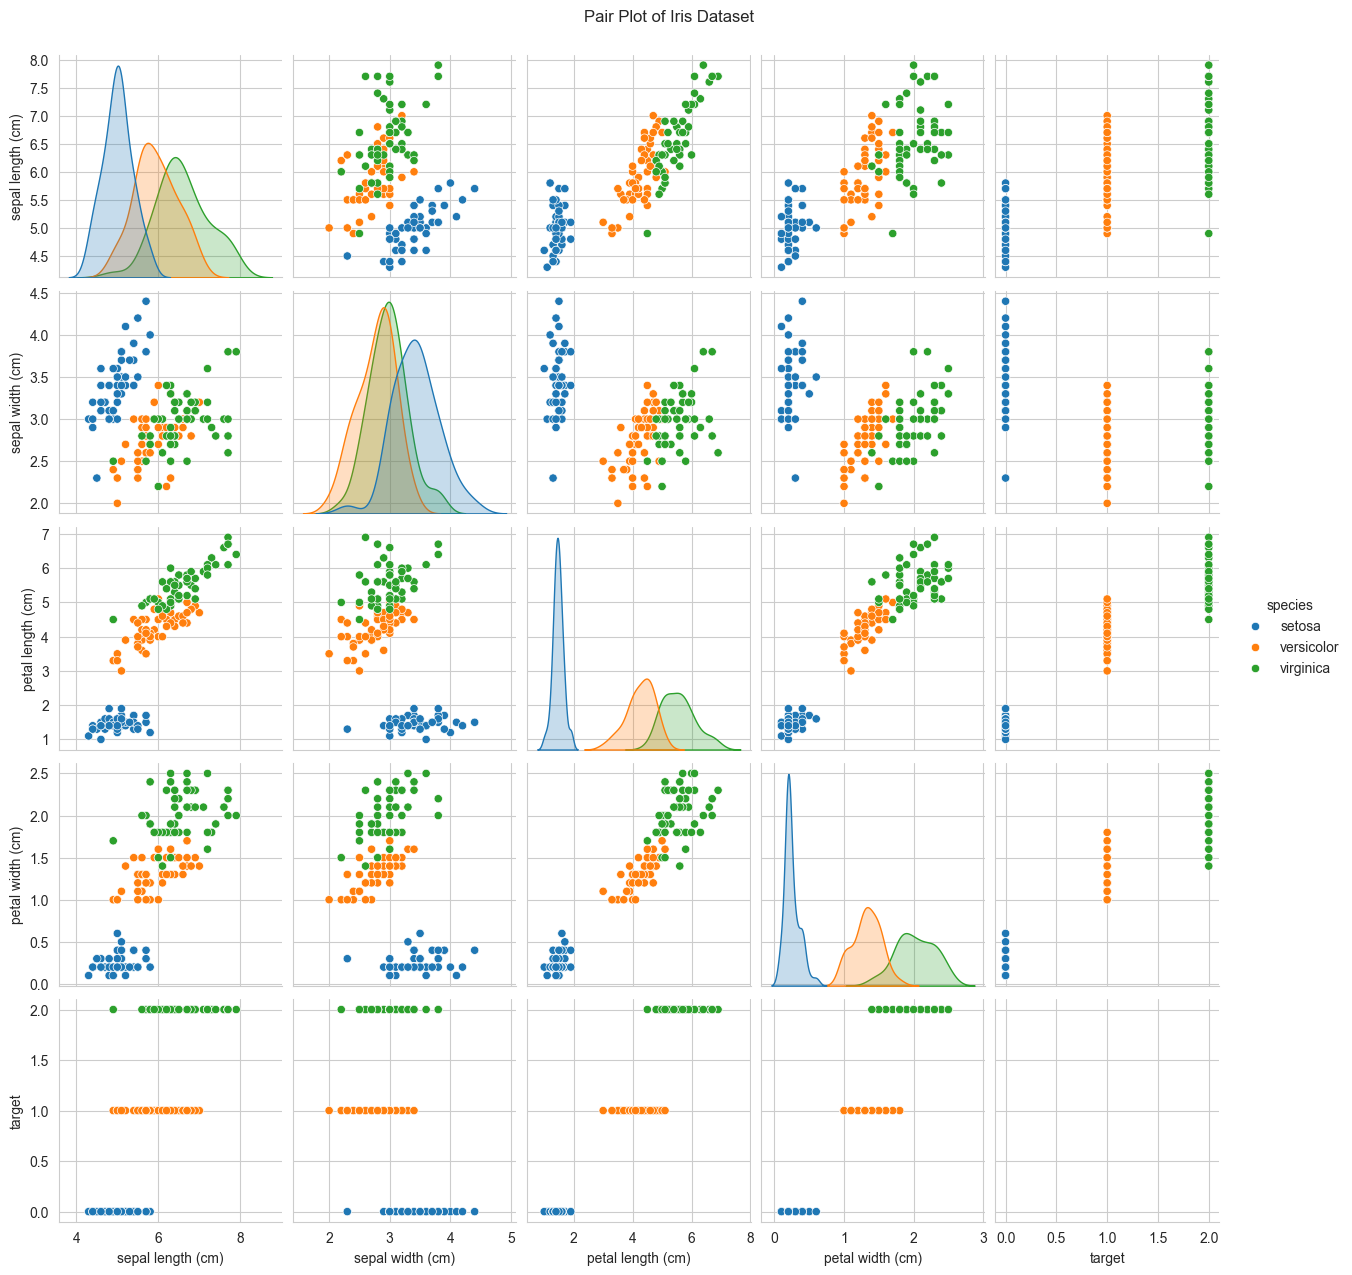

In [10]:
# Pair plot to visualize relationships
# This is a powerful command to see realtionships between all pairs of features
# and the distribution of each feature, colored by the target variable.
sns.pairplot(df, hue = 'species', height=2.5)
plt.suptitle('Pair Plot of Iris Dataset', y=1.02);

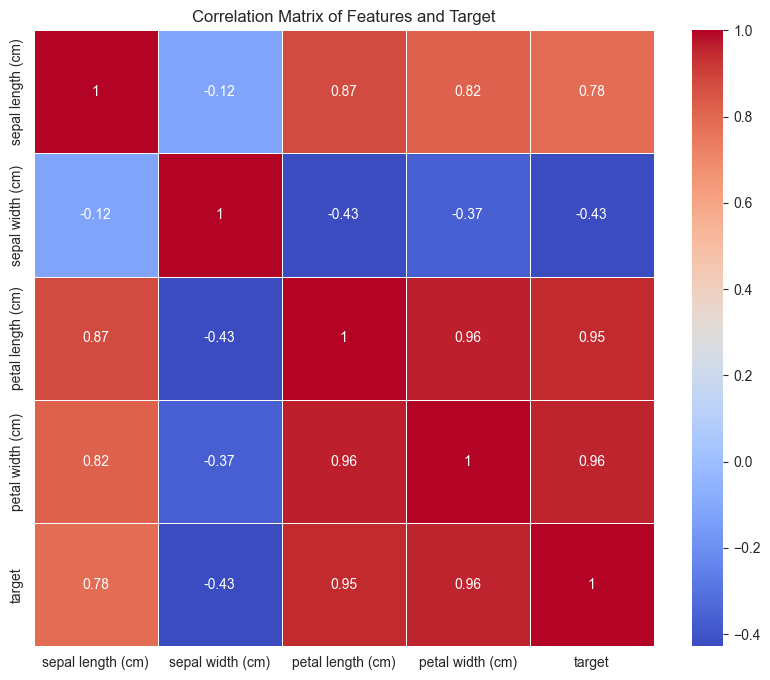

In [11]:
# Correlation Matric Heatmap
# Select Only numeric features or columns for correlation
df_num = df.drop(columns=['species'])
plt.figure(figsize=(10,8))
corr_mat  = df_num.corr() # Built in function in pandas
sns.heatmap(corr_mat,
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)
plt.title('Correlation Matrix of Features and Target')
plt.show()

## Minimal Working Example : 
> Load -> Split -> Train -> Predict -> Evaluate

In [12]:
# IMports
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# For reproducible results
np.random.seed(42)


In [13]:
# Load the data
# We have already loaded the data, So there is no need to re-load it

# Let's split the data into Features and Label
#                OR
#                                  X and  y
X = df.drop(['target', 'species'], axis=1)
y = df['target']

print(F"Features Shape : {X.shape}")
print(F"Target Shape : {y.shape}")

# Another way of doing is : 
# Less common
X, y  = load_iris(return_X_y=True)

print(F"Features Shape : {X.shape}")
print(F"Target Shape : {y.shape}")
print("\nSee Same thing")

Features Shape : (150, 4)
Target Shape : (150,)
Features Shape : (150, 4)
Target Shape : (150,)

See Same thing


In [14]:
# Split DATA
# Split the data into Training ( 80% ) and testing ( 20% ) sets.
# stratify = y ensures that the proportion of classes in the train and test sets
# is the same as the original dataset.

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y
                                                    )

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (120, 4)
X_test shape: (30, 4)


In [15]:
# Train Mode
# 1. Instantiate the estimator (create the model object)
# we'll use Logistic Regression, a simple and powerfull classification model
model = LogisticRegression(max_iter=200) # INcreased max_iter for convergence

# Fit the model to the training data
model.fit(X_train, y_train)
print("model training complete")

model training complete


In [16]:
# Predict
# Use the trained model to make predictions on the unseen data.
y_pred = model.predict(X_test)
print(f"First 5 predictions : {y_pred[:5]}")
print(f"First 5 actual labels : {y_test[:5]}")


First 5 predictions : [0 2 1 1 0]
First 5 actual labels : [0 2 1 1 0]


In [17]:
# Evaluate the model
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {100 * accuracy:.2f}%")

Accuracy: 96.67%


____
#### Interpretation - The Model Coefficients
> The magic of a model lies in its coefficients. The model learned one coefficient for each feature, for each class

In [42]:
print(f"Model Coefficients shape : {model.coef_.shape}")
print(f"Model Intercept Shape: {model.intercept_.shape}")
print(f"Classes : {iris.target_names}")

# Create a DataFRame for easy viewing
coef_df = pd.DataFrame(model.coef_, columns=iris.feature_names,
                       index=iris.target_names)
print("model Coefficients")
print("""\nmodel.coef_: This attribute stores the learned weights for
             each feature. Since we have 3 classes and 4 features,
             the shape is (3, 4).
\nEach row corresponds to a class ('setosa', 'versicolor', 'virginica').
\nEach column corresponds to a feature.
\nA large positive coefficient means that a high value for that feature increases the probability of that class.
A large negative coefficient means that a high value for that feature decreases the probability of that class.""")
coef_df

Model Coefficients shape : (3, 4)
Model Intercept Shape: (3,)
Classes : ['setosa' 'versicolor' 'virginica']
model Coefficients

model.coef_: This attribute stores the learned weights for
             each feature. Since we have 3 classes and 4 features,
             the shape is (3, 4).

Each row corresponds to a class ('setosa', 'versicolor', 'virginica').

Each column corresponds to a feature.

A large positive coefficient means that a high value for that feature increases the probability of that class.
A large negative coefficient means that a high value for that feature decreases the probability of that class.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-0.529545,0.827265,-2.347373,-0.993393
versicolor,0.529710,-0.304722,-0.170954,-0.856068
virginica,-0.000165,-0.522543,2.518327,1.849461


**Visualizing Feature IMportance with ELI5**

In [29]:
# Humans respond to visualization. 
# Let's plot the coefficients
# ELI5 (Explain it Like Iam 5) is a great library for quick, simple model_interp
# !uv add eli5
# or 
# !pip install eli5

import eli5

# Show the weights for our trained model
eli5.show_weights(model,
                  feature_names=iris.feature_names,
                  target_names = iris.target_names,)

## Wow that is a nice model. Isn't it?


## Variations & Key Concepts
The beauty of Sklearn is its consistency. Let's swap the model. Notice how little the code changes.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate a new model
new_model = KNeighborsClassifier(n_neighbors=5)

# Fit the model OR Train the model
new_model.fit(X_train, y_train)

# Predict
y_pred_new  = new_model.predict(X_test)

# Evaluate 
accuracy_knn = accuracy_score(y_test, y_pred_new)
print(f"Accuracy: {100 * accuracy_knn:.2f}%")

Accuracy: 100.00%


Many models can also predict probabilities, which is often more useful than a hard prediction

In [19]:
# Getting Probabilities
# Get the probabilities for each class for the first 5 test samples
probabilities = model.predict_proba(X_test[:5])

print("Probabilities for first 5 samples : ")
np.set_printoptions(precision=3, suppress=True)
print(probabilities)

print("\nPredicted class for first sample:", np.argmax(probabilities[0]))


Probabilities for first 5 samples : 
[[0.985 0.015 0.   ]
 [0.001 0.391 0.608]
 [0.187 0.809 0.004]
 [0.156 0.84  0.004]
 [0.988 0.012 0.   ]]

Predicted class for first sample: 0


# Common Pitfalls and Mistakes : 
    1. **Training and Testing on the Same Data (Data Leakage):** This is the #1 mistake. It gives you a perfect completely useless score 

In [20]:
# DO NOT DO THIS
model_leaky = LogisticRegression(max_iter=200)
model_leaky.fit(X, y) # Fit on ALL data

leaky_preds = model_leaky.predict(X) # Predict on the SAME data

leaky_accuracy = accuracy_score(y, leaky_preds)
print(f"Dangerously optimistic accuracy: {leaky_accuracy * 100:.2f}%") # This is meaningless!

Dangerously optimistic accuracy: 97.33%


    2. **Forgetting to INstantiate the Model:** You must create an *instance* of the model class by using parenthesis()

In [21]:
# Wrong way
try:
    LogisticRegression.fit(X_train, y_train)
except Exception as e:
    print(f"Error: {e}")

# Correct way
model = LogisticRegression(max_iter=200) # Correct: creates an instance
model.fit(X_train, y_train)
print("\nModel fitted correctly after instantiation.")

Error: 'numpy.ndarray' object has no attribute '_validate_params'

Model fitted correctly after instantiation.


#### Congratulations. You have just successfully trained, predicted with, and evaluated your first two machine learning models using the standard, professional workflow. You've seen the core scikit-learn API (`fit`, `predict`) and used the most critical function for model validation (`train_test_split`).